In [2]:
library(tidyverse)

In [3]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] en_GB.UTF-8/en_GB.UTF-8/en_GB.UTF-8/C/en_GB.UTF-8/en_GB.UTF-8

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4    
 [5] purrr_1.0.2     readr_2.1.5     tidyr_1.3.1     tibble_3.2.1   
 [9] ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        digest_0.6.36      uuid_1.2-0         timechange_0.3.0  
 [9] jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4    gtable_0.3.6      
[13] pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1      cli_3.6.3         
[17] IRkernel_1.3.2     fastmap_1.2.0      

In [10]:
truth_references <- read_csv("truth-references.csv")

Rows: 20 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Accession, segment, species

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
truth_references

Accession,segment,species
<chr>,<chr>,<chr>
KY484043.1,L,CCHF
AY900143.1,M,CCHF
MH396657.1,S,CCHF
KY785988.1,NA,EBOV
JX008756.1,1,FLU
KU318987.1,2,FLU
KC833440.1,3,FLU
KY551371.1,4,FLU
KP638526.1,5,FLU


In [ ]:
system("mkdir -p truth-references")
apply(truth_references, 1, function(x) {
  acc <- x[1]
  species <- x[3]
  system(paste0("cat ncbi-virus-fasta/sequences_*_", species, ".fasta | seqkit grep  -r -p ", acc, "  > truth-references/", acc,"_", species, ".fasta"))
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [13]:
# Run mmseqs for every reference against the complete references
system("mkdir -p mmseqs-results")
apply(truth_references, 1, function(x) {
  acc <- x[1]
  species <- x[3]
  system(paste0("conda run -n mmseqs2-env mmseqs easy-search --search-type 3 truth-references/", acc,"_", species, ".fasta ncbi-virus-fasta/sequences_20251001_",species,".fasta mmseqs-results/", acc,"_mmseqs.out.m8 tmp"))
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [31]:
colnames_mmseqs <- str_split("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits", ",")[[1]]

mmseqs <- list.files("mmseqs-results/")%>%
    map_dfr(~ read_delim(paste0("mmseqs-results/", .), "\t", col_names = colnames_mmseqs))%>%
    group_by(query)%>%
    filter(alnlen > max(alnlen)/2) %>% # filter to only those with at least half of the median alignment length
    ungroup()%>%
    merge(.,truth_references, by.x = "query", by.y = "Accession", all.x = TRUE)


Rows: 107 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 639 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 197 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to re

In [32]:
head(mmseqs)

,query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,segment,species
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,AY900143.1,AY900143.1,1.000,5100,0,0,1,5100,1,5100,0,9139,M,CCHF
2,AY900143.1,KY484047.1,0.999,5100,5,0,1,5100,81,5180,0,9125,M,CCHF
3,AY900143.1,DQ019222.1,0.999,5100,5,0,1,5100,81,5180,0,9121,M,CCHF
4,AY900143.1,MH396671.1,0.838,4437,719,0,660,5096,714,5150,0,4739,M,CCHF
5,AY900143.1,MH396665.1,0.838,4437,719,0,660,5096,767,5203,0,4739,M,CCHF
6,AY900143.1,GU477493.1,0.833,4449,743,0,652,5100,723,5171,0,4657,M,CCHF


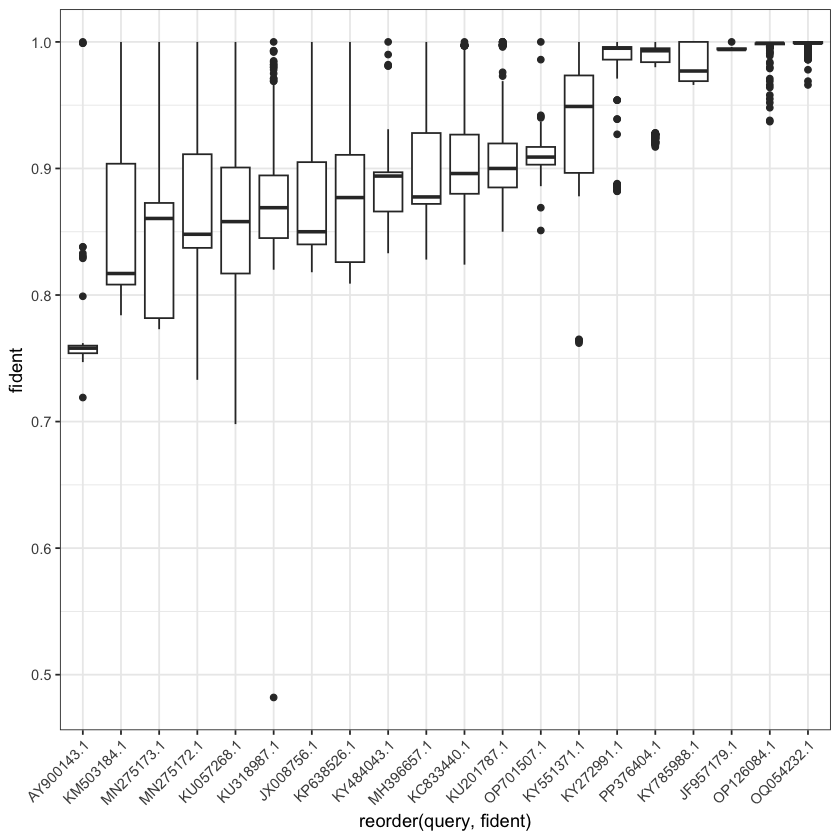

In [33]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(mmseqs, aes(y = fident, x = reorder(query, fident))) +
  geom_boxplot() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [34]:
set.seed(42)
# Selecting a reference for each query in a window of [[80,82],[82,84],...,[98,100]]
selected_references <- mmseqs %>%
  filter(fident >=0.8) %>%
  mutate(fident_window = cut(fident, breaks = seq(0.8, 1, by = 0.02), include.lowest = TRUE)) %>%
  group_by(query, fident_window) %>%
  sample_n(size = 1, weight = alnlen)

In [35]:
mmseqs%>%filter(species=="MPX")

query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,segment,species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
OQ054232.1,OQ557946.1,1,10000,0,0,80001,90000,80001,90000,0,17918,NA,MPX
OQ054232.1,OQ557946.1,1,10000,0,0,100001,110000,100001,110000,0,17918,NA,MPX
OQ054232.1,OQ557946.1,1,10000,0,0,20001,30000,20001,30000,0,17918,NA,MPX
OQ054232.1,OQ557946.1,1,10000,0,0,30001,40000,30001,40000,0,17918,NA,MPX
OQ054232.1,OQ557946.1,1,10000,0,0,70001,80000,70001,80000,0,17918,NA,MPX
OQ054232.1,OQ427118.1,1,10000,0,0,140001,150000,140001,150000,0,17918,NA,MPX
OQ054232.1,OQ427118.1,1,10000,0,0,160001,170000,160001,170000,0,17918,NA,MPX
OQ054232.1,OP484672.1,1,10000,0,0,160001,170000,160001,170000,0,17918,NA,MPX
OQ054232.1,OP215242.1,1,10000,0,0,160001,170000,160001,170000,0,17918,NA,MPX


In [36]:
selected_references

query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,segment,species,fident_window
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>
AY900143.1,MH396671.1,0.838,4437,719,0,660,5096,714,5150,0,4739,M,CCHF,"(0.82,0.84]"
AY900143.1,AY900143.1,1.000,5100,0,0,1,5100,1,5100,0,9139,M,CCHF,"(0.98,1]"
JF957179.1,KJ501384.1,0.994,10000,60,0,1,10000,1,10000,0,17689,NA,WNV,"(0.98,1]"
JX008756.1,KP027612.1,0.818,1969,358,0,43,2011,1,1969,0,1926,1,FLU,"[0.8,0.82]"
JX008756.1,KM609848.1,0.839,2279,367,0,1,2279,28,2306,0,2450,1,FLU,"(0.82,0.84]"
JX008756.1,JQ673589.1,0.843,2280,358,0,1,2280,10,2289,0,2487,1,FLU,"(0.84,0.86]"
JX008756.1,JX416725.1,0.861,2280,317,0,1,2280,28,2307,0,2671,1,FLU,"(0.86,0.88]"
JX008756.1,KY551456.1,0.895,2280,239,0,1,2280,13,2292,0,3020,1,FLU,"(0.88,0.9]"
JX008756.1,EU084932.1,0.901,2280,226,0,1,2280,4,2283,0,3083,1,FLU,"(0.9,0.92]"


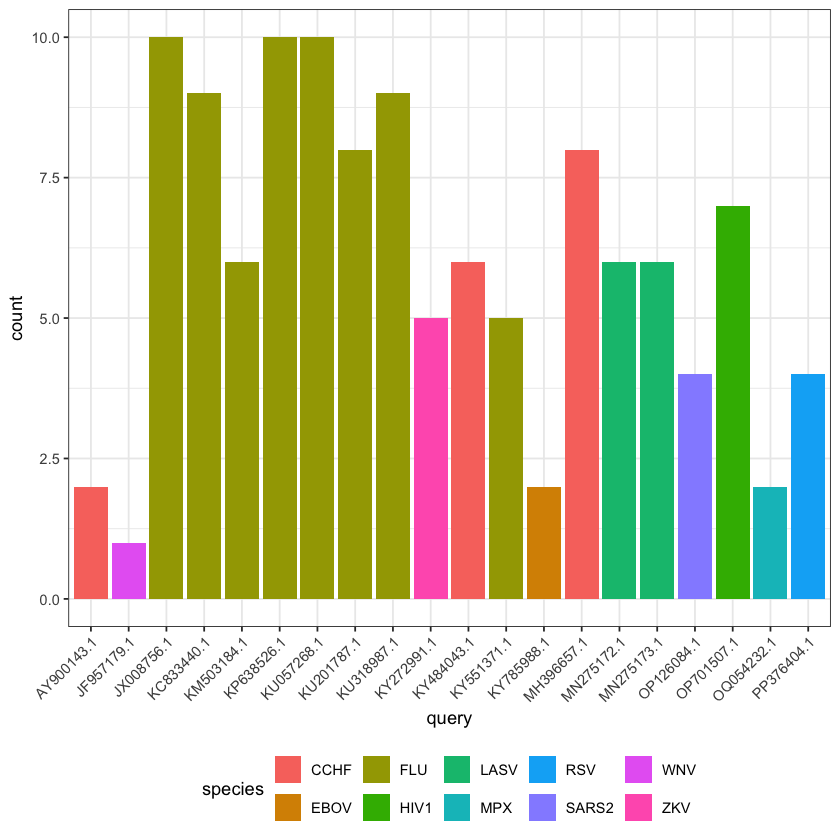

In [37]:
# Checking how many we have for every query
ggplot(selected_references, aes(x = query, fill = species)) +
  geom_bar() +
  theme_bw() +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

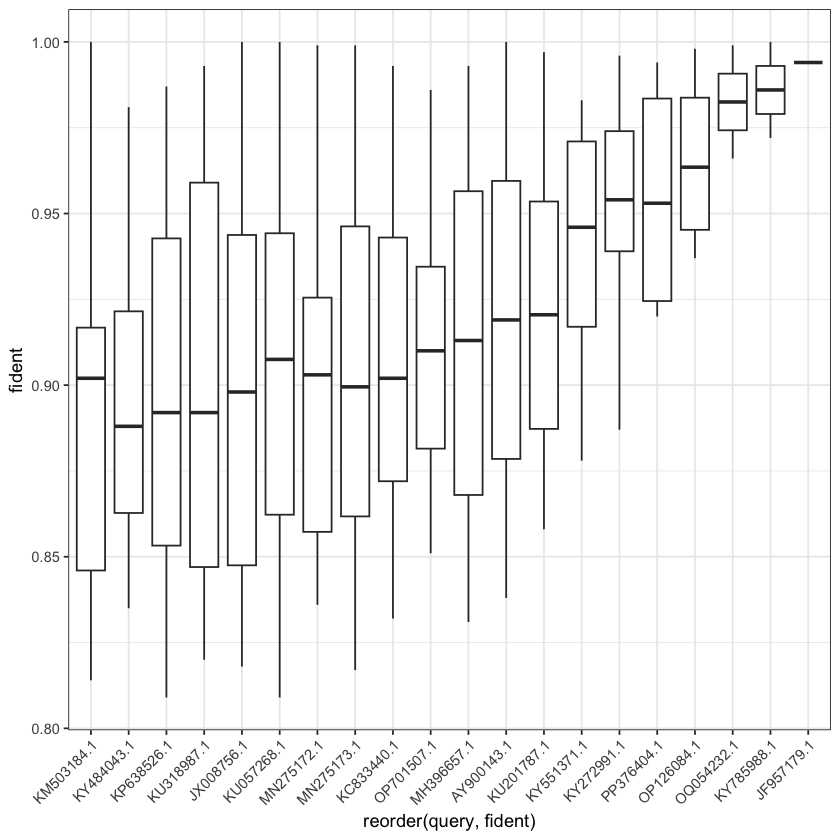

In [38]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = fident, x = reorder(query, fident))) +
  geom_boxplot() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))